# BTC Direction Classification — Time-Series Ensemble

Multi-model walk-forward framework for predicting 24-hour BTC price direction (up/down) using hourly OHLCV features from 2020-2023.

**Models:** XGBoost · CatBoost · LightGBM · Random Forest · ElasticNet · MiniRocket  
**Tuning:** Optuna (TPE, minimise log-loss) per fold  
**Validation:** Expanding-window walk-forward with purge + embargo · 5 000-bar hold-out set  
**Meta-labelling:** second-layer filter to gate low-confidence trades

## 1. Setup & Dependencies

In [1]:
!pip install hmmlearn ruptures pandas sktime mlflow tslearn tqdm xgboost tsfresh scikit-learn matplotlib seaborn catboost lightgbm optuna
!pip install -U aeon

  Using cached sktime-0.40.1-py3-none-any.whl.metadata (33 kB)
  Using cached tsfresh-0.21.1-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached sktime-0.40.1-py3-none-any.whl (36.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 30.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Seed & Reproducibility

In [2]:
import os, random, numpy as np
os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)


## 3. Data Loading & EDA

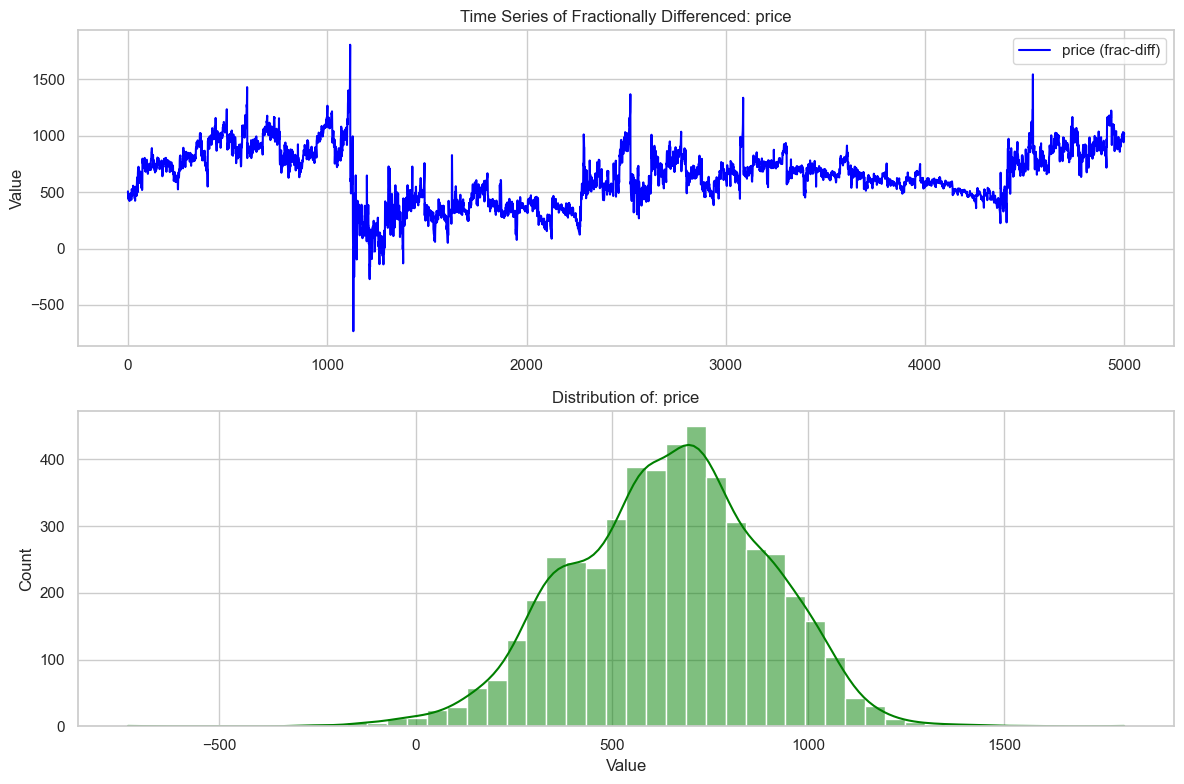

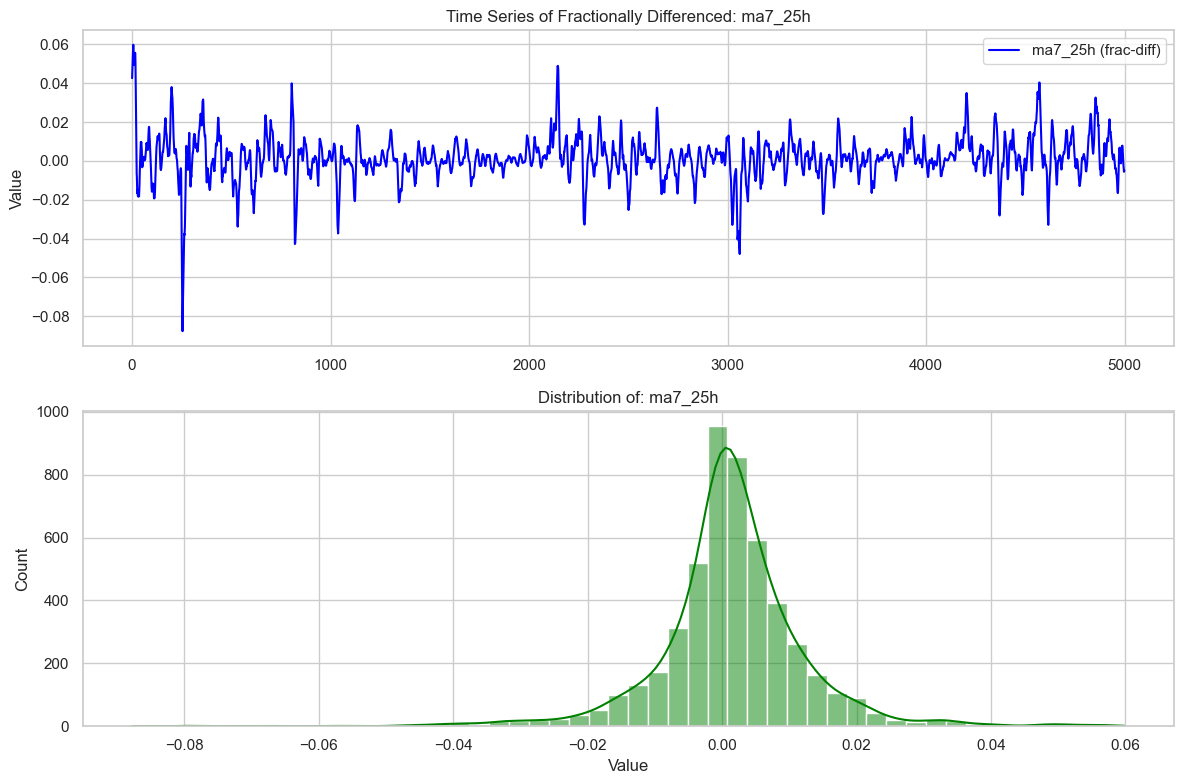

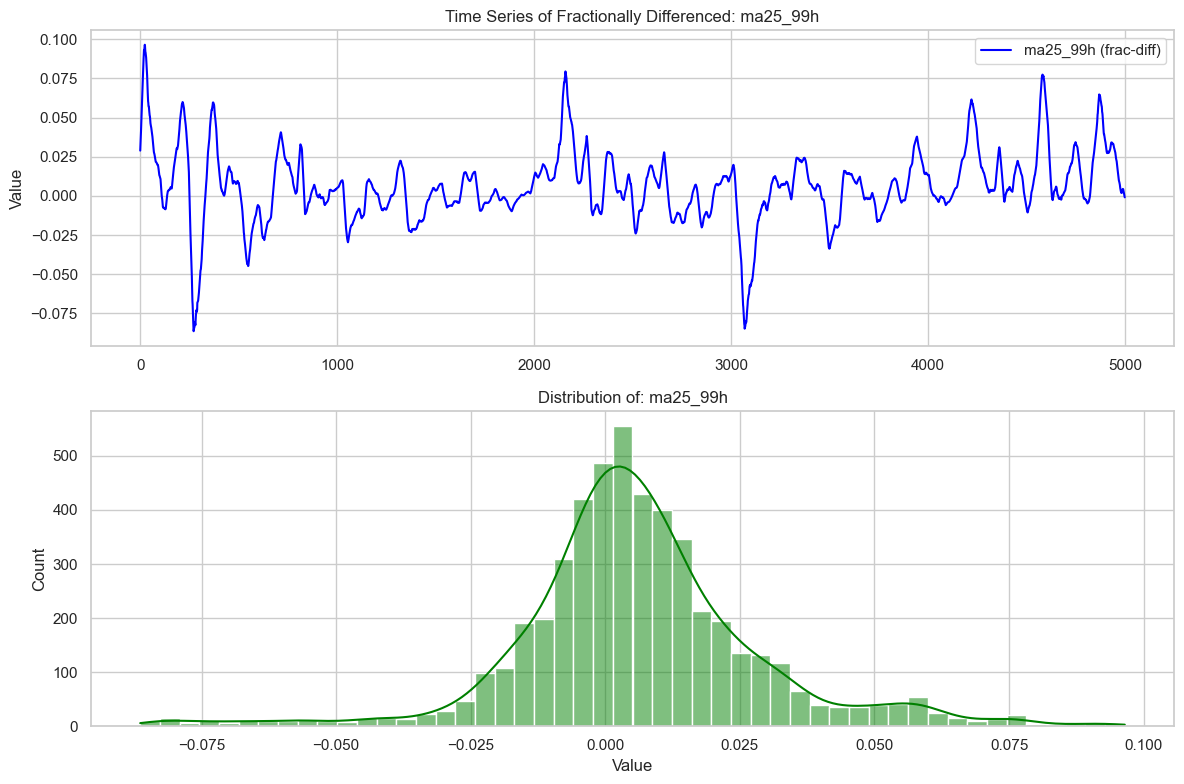

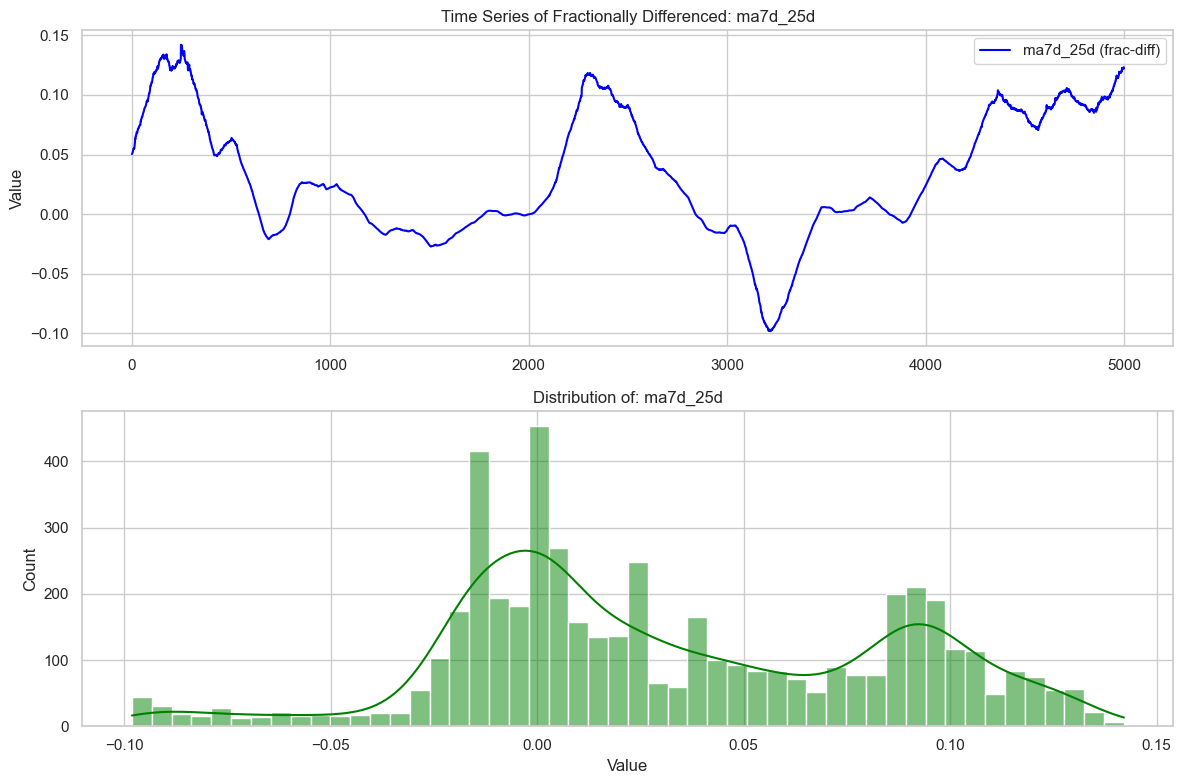

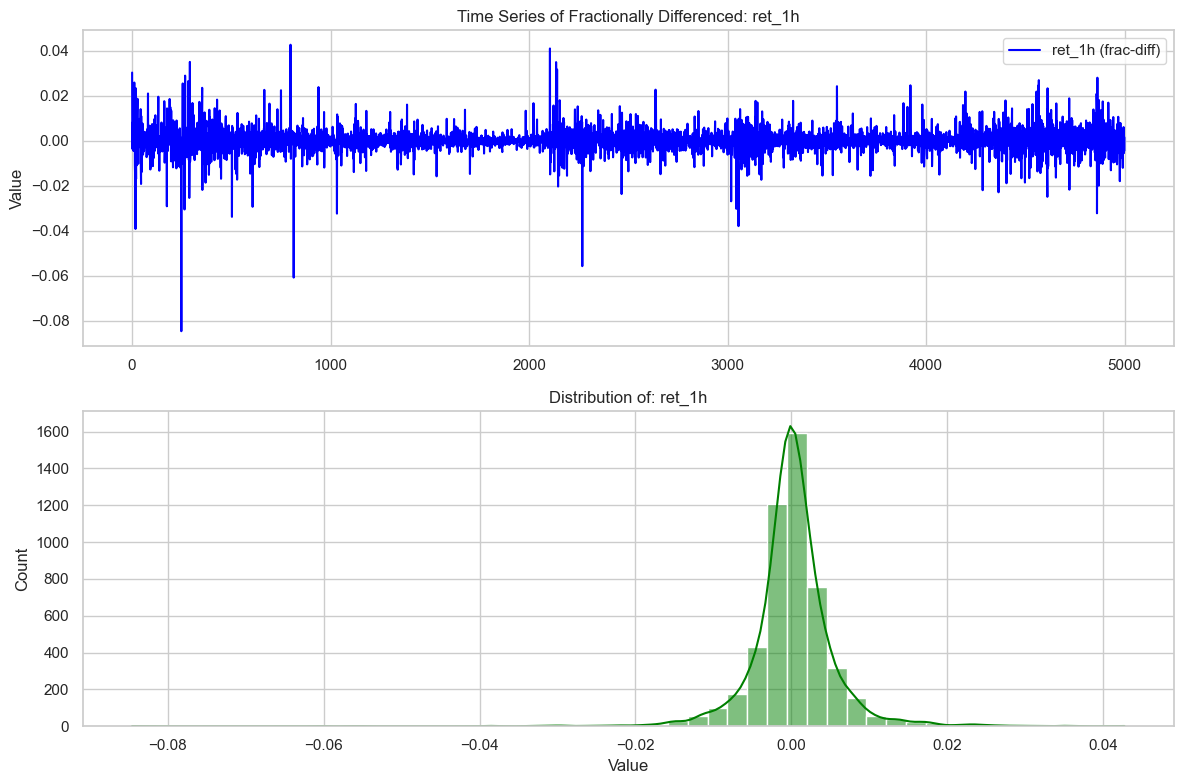

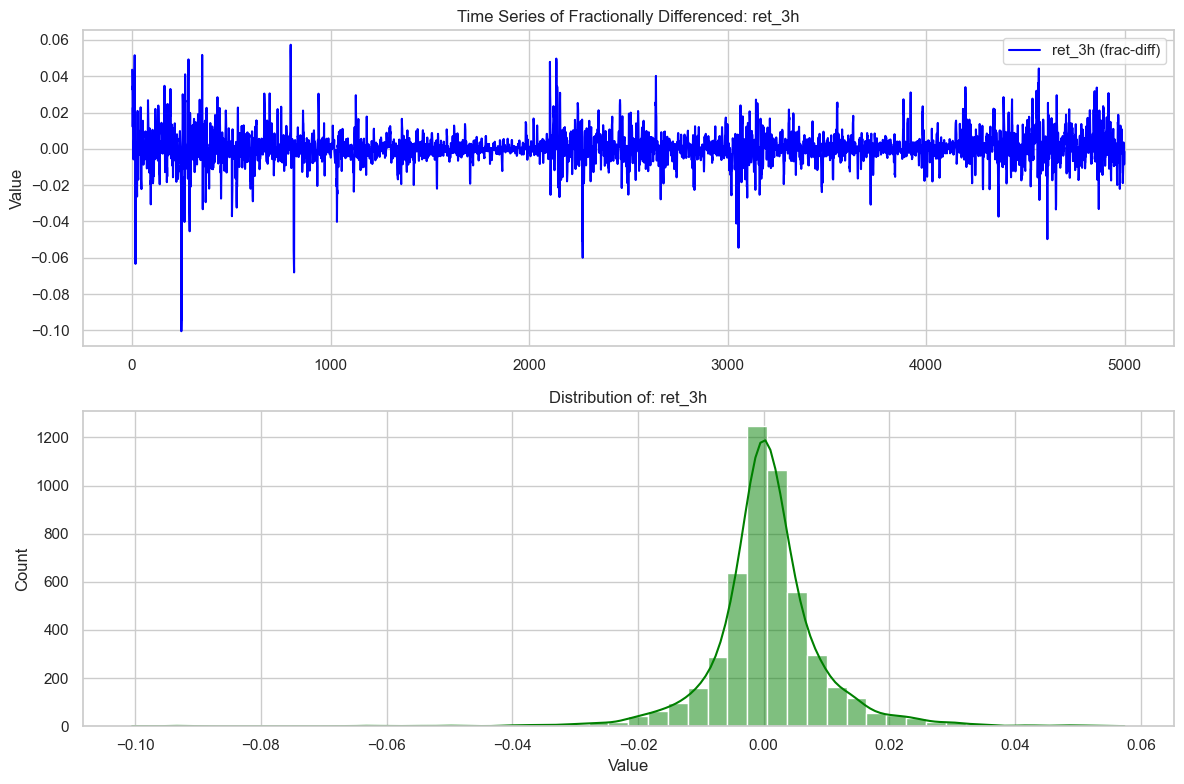

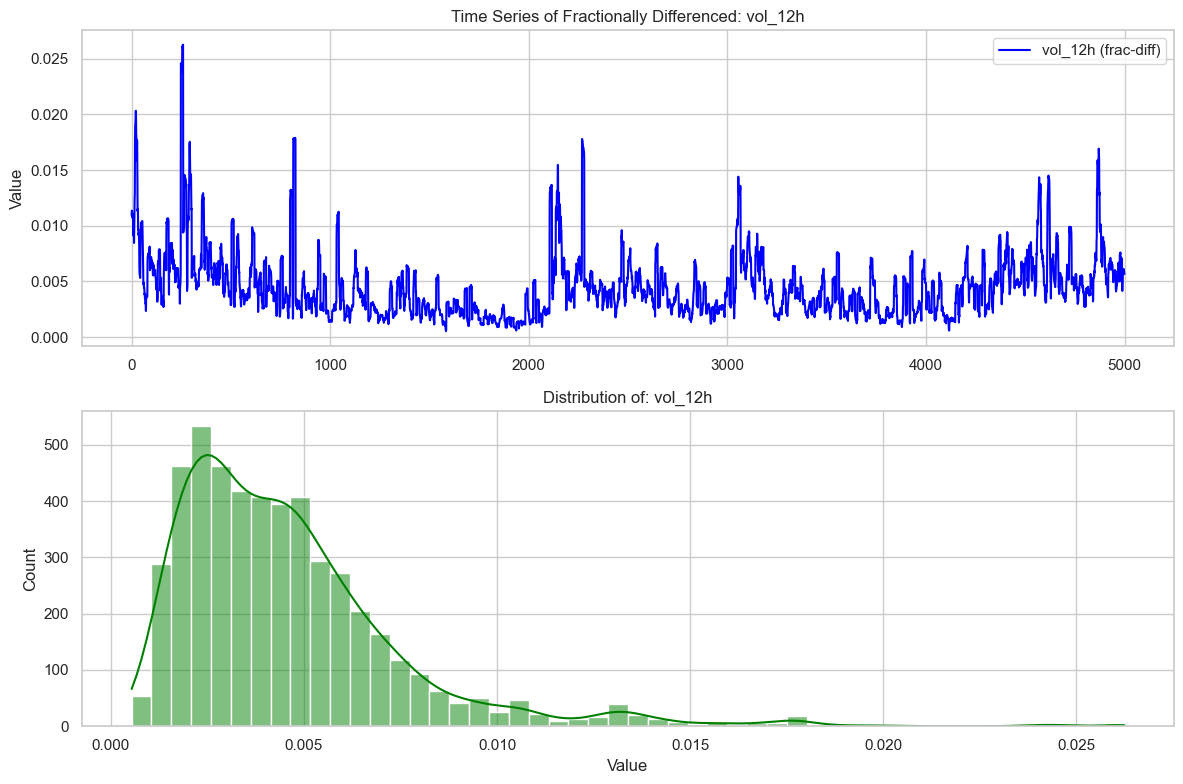

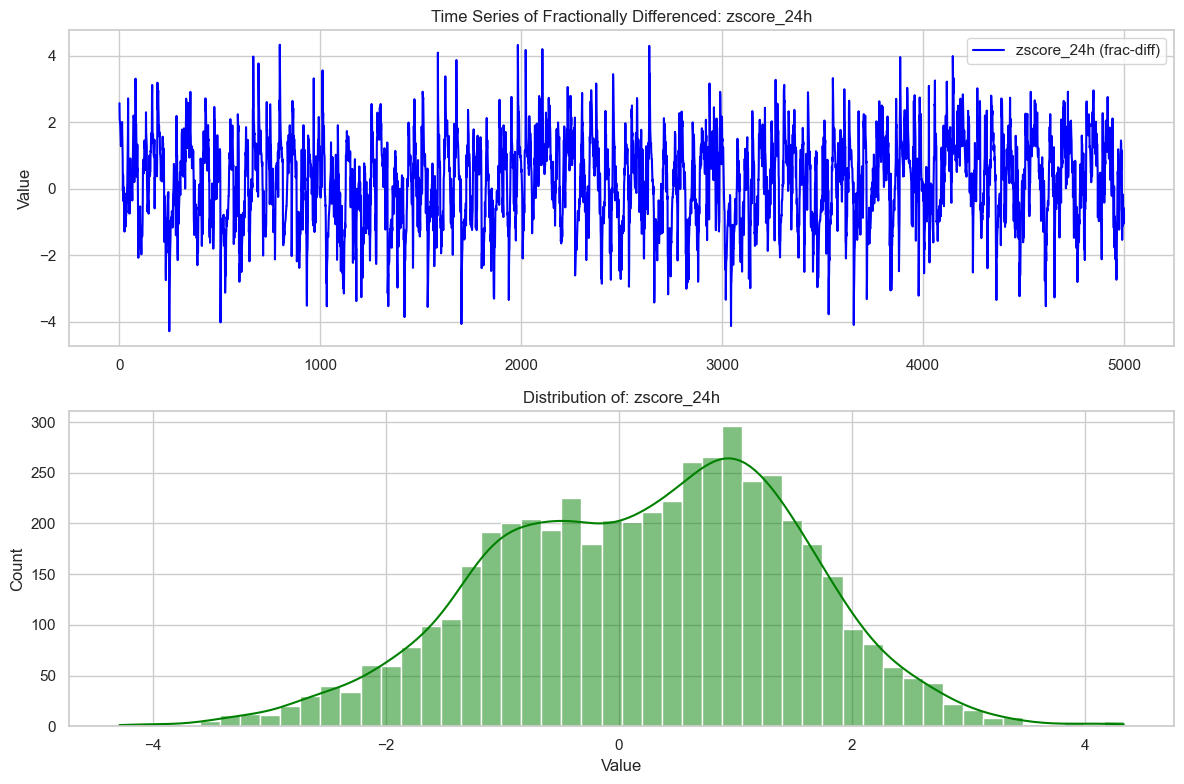

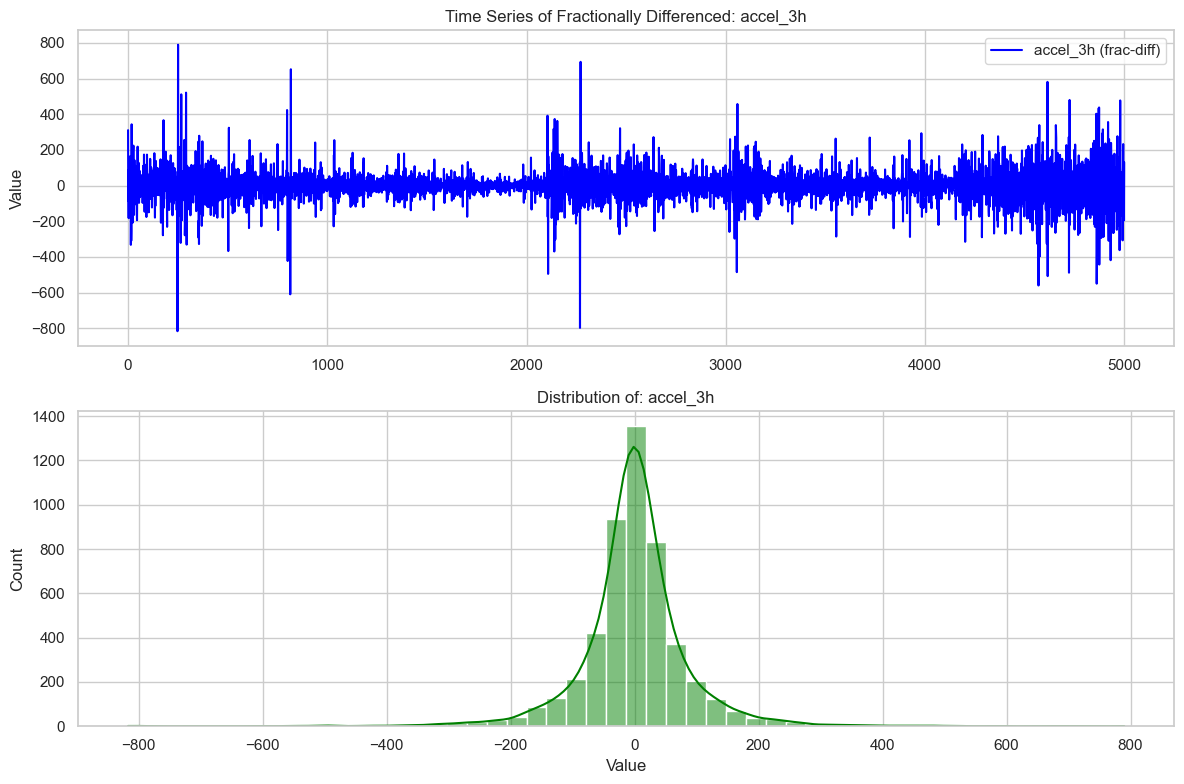

In [14]:
import pandas as pd

# Using sample.csv (first 500 rows); replace with the full dataset for complete EDA
filepath = 'data/sample.csv'


transformed_df = pd.read_csv(filepath)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are shown in higher quality
sns.set(style="whitegrid", context="notebook")

for column in transformed_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

    # Plot time series
    axes[0].plot(transformed_df[column], label=f'{column} (frac-diff)', color='blue')
    axes[0].set_title(f'Time Series of Fractionally Differenced: {column}')
    axes[0].set_ylabel('Value')
    axes[0].legend()

    # Plot distribution (histogram + KDE)
    sns.histplot(transformed_df[column], kde=True, ax=axes[1], bins=50, color='green')
    axes[1].set_title(f'Distribution of: {column}')
    axes[1].set_xlabel('Value')

    plt.tight_layout()
    plt.show()

In [15]:
transformed_df.head()
num_rows = transformed_df.shape[0]
print(num_rows)

5000


## 4. Model Configuration & Feature Engineering

In [19]:
# ================================================================
# 0  Imports
# ================================================================
import numpy as np
import pandas as pd
from sklearn.ensemble   import GradientBoostingClassifier
import optuna, mlflow
from sklearn.model_selection import cross_val_score
from xgboost   import XGBClassifier
from catboost  import CatBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from mlflow.exceptions import MlflowException
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix,make_scorer, classification_report
from sklearn.ensemble       import ExtraTreesRegressor
from sklearn.linear_model   import ElasticNet, HuberRegressor, SGDClassifier
from catboost               import CatBoostRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from lightgbm              import LGBMClassifier
from sklearn.base import clone
from sklearn.base import BaseEstimator, ClassifierMixin
from sktime.transformations.panel.rocket import MiniRocket
from sklearn.linear_model import RidgeClassifierCV
from sklearn.pipeline import Pipeline
from sktime.utils.validation.panel import check_X
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
import inspect
from sklearn.metrics import make_scorer, log_loss
import math

try:
    from aeon.classification.hybrid import HIVECOTEV2 as _HIVECOTE_CLASS
except Exception:
    try:
        from sktime.classification.hybrid import HIVECOTEV1 as _HIVECOTE_CLASS
    except Exception:
        _HIVECOTE_CLASS = None

# ================================================================
# 1  Configuration, Utility
# ================================================================

HORIZON        = 24         # predict 24 h (~1 day) ahead

THRESH_RET     = 0.01      # % up / down threshold
EMBARGO        = 24         # 24 h buffer between train & test slices
STEP_SIZE      = math.ceil(num_rows * 0.15)      # number of data rows perfold
PASS_LABEL     = 1          # up  label
FAIL_LABEL     = 0          # down label

MLFLOW_URI = "mlruns"
mlflow.set_tracking_uri(MLFLOW_URI)


# ================================================================
# 2  Fixed-Horizon Binary Labels
# ================================================================
# ---- 2.1 forward return over HORIZON bars (24 h) ---------------
fwd_ret = transformed_df['price'].shift(-HORIZON) / transformed_df['price'] - 1
fwd_ret = fwd_ret.dropna()

# ---- 2.2 encode:  1 = up, 0 = down --------------
y = (fwd_ret >= 0).astype(int)


 
# ---- 2.3 align the feature matrix ------------------------------
# keep only rows that have a valid label

BASE_FEATURES = [
    "price","ma7_25h","ma25_99h","ma7d_25d",
    "ret_1h","ret_3h","vol_12h","zscore_24h","accel_3h",
]


X = transformed_df.loc[y.index, BASE_FEATURES]

# ---- meta feature: rolling variance over mean price squared ----
price = transformed_df.loc[y.index, "price"]
roll_mean_24 = price.rolling(24).mean()
roll_var_24  = price.rolling(24).var()
var_over_mean_sq_24 = roll_var_24 / (roll_mean_24 ** 2)
roll_mean_168 = price.rolling(168).mean()
pct_over_prev_168 = price / roll_mean_168 - 1

HOLD_OUT_SIZE = math.ceil(num_rows * 0.15)               # ≈ around last x hourly bars given that x is hold out size
holdout_X = X.tail(HOLD_OUT_SIZE)
holdout_y = y.tail(HOLD_OUT_SIZE)

X= X.iloc[:-HOLD_OUT_SIZE]     # data used for walk-forward
y= y.iloc[:-HOLD_OUT_SIZE]

ALIGN_WIN=24
# ================================================================
# 3  OPTUNA OBJECTIVES — minimise LOG-LOSS
# ================================================================

from sklearn.metrics import log_loss, make_scorer

def reg_neg_logloss(y_true, y_pred):
    prob = 1.0 / (1.0 + np.exp(-y_pred))  # sigmoid
    return -log_loss(y_true, prob)


LOGLOSS_SCORER = make_scorer(reg_neg_logloss, greater_is_better=True)

def obj_xgb(trial):
    params = dict(
        objective       ="binary:logistic",
        eval_metric     ="logloss",
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.15),
        max_depth        = trial.suggest_int("max_depth", 3, 7),
        subsample        = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.3, 1.0),
        n_estimators     = trial.suggest_int("n_estimators", 200, 1000),
        random_state    = 42,
    )
    clf   = XGBClassifier(**params)
    score = cross_val_score(
        clf, X_fold, y_fold, cv=TimeSeriesSplit(n_splits=3, gap=HORIZON), scoring="neg_log_loss"
    ).mean()
    return -score                       # minimise positive log-loss

def obj_cat(trial):
    params = dict(
        depth         = trial.suggest_int("depth", 4, 10),
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3),
        iterations    = trial.suggest_int("iterations", 200, 1000),
        loss_function = "Logloss",
        eval_metric   = "Logloss",
        verbose       = 0,
        random_seed   = 42,
    )
    clf   = CatBoostClassifier(**params)
    score = cross_val_score(
        clf, X_fold, y_fold, cv=TimeSeriesSplit(n_splits=3, gap=HORIZON), scoring="neg_log_loss"
    ).mean()
    return -score

def obj_enet(trial):
    pipe = make_pipeline(
        StandardScaler(),
        SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            class_weight="balanced",
            max_iter=10_000,
            random_state=42,
        ),
    )
    pipe.set_params(**{
        "sgdclassifier__alpha": trial.suggest_float("sgdclassifier__alpha", 1e-5, 1e-1, log=True),
        "sgdclassifier__l1_ratio": trial.suggest_float("sgdclassifier__l1_ratio", 0.0, 1.0),
    })
    score = cross_val_score(
        pipe, X_fold, y_fold,
        cv=TimeSeriesSplit(n_splits=3, gap=HORIZON),
        scoring="neg_log_loss",   # SGDClassifier has predict_proba
        n_jobs=-1
    ).mean()
    return -score
def obj_rf(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 1000),
        max_depth         = trial.suggest_int("max_depth", 4, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 20),
        max_features      = trial.suggest_float("max_features", 0.3, 1.0),
        class_weight      = "balanced",
        n_jobs            = -1,
        random_state      = 42,
    )
    clf = RandomForestClassifier(**params)
    score = cross_val_score(
        clf, X_fold, y_fold, cv=TimeSeriesSplit(n_splits=3, gap=HORIZON), scoring="neg_log_loss", n_jobs=-1
    ).mean()
    return -score

# -----------------------------------------------------------------
#  LightGBM Classifier   
# -----------------------------------------------------------------
def obj_lgb(trial):
    params = dict(
        learning_rate   = trial.suggest_float("lr", 0.01, 0.3, log=True),
        n_estimators    = trial.suggest_int("n_est", 200, 1000),
        num_leaves      = trial.suggest_int("num_leaves", 16, 128),
        max_depth       = trial.suggest_int("max_depth", -1, 16),
        subsample       = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree= trial.suggest_float("colsample", 0.5, 1.0),
        objective       = "binary",
        random_state    = 42,
        class_weight    = "balanced",
        n_jobs          = -1,
        **{"verbosity": -1},
    )
    clf = LGBMClassifier(**params)
    score = cross_val_score(
        clf, X_fold, y_fold, cv=TimeSeriesSplit(n_splits=3, gap=HORIZON), scoring="neg_log_loss"
    ).mean()
    return -score

# -----------------------------------------------------------------
#  Rocket Model
# -----------------------------------------------------------------

def make_ts_dataset(X_df, y_ser, window=24):
    # Ensure aligned, consecutive integer index
    X_df = X_df.reset_index(drop=True)
    y_ser = y_ser.reset_index(drop=True)

    X_ts, y_ts = [], []
    for i in range(window, len(X_df)):
        X_window = X_df.iloc[i - window:i].values.T  # shape: [n_features, window]
        if y_ser.iloc[i] in [0, 1]:  # binary target only
            X_ts.append(X_window)
            y_ts.append(y_ser.iloc[i])

    return np.array(X_ts), np.array(y_ts)

def obj_rocket(trial):
    X_, y_ = make_ts_dataset(X_fold, y_fold, window=24)
    rocket = MiniRocket()
    pipe = Pipeline([
        ("rocket", MiniRocket()),
        ("clf", LogisticRegression(
          C=trial.suggest_float("C", 1e-5, 1e-1, log=True),
          solver="lbfgs",
          max_iter=10000  # Increased to help convergence
          ))
        ])
    score = cross_val_score(pipe, X_, y_, cv=TimeSeriesSplit(n_splits=3, gap=HORIZON) , scoring="neg_log_loss").mean()
    return -score

class MiniRocketLogisticWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, window=24, C=1.0):
        self.window = window
        self.C = C
        self.rocket = MiniRocket()
        self.classifier = LogisticRegression(C=self.C, max_iter=10000, solver="lbfgs")
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier"

    def fit(self, X, y):
        X_ts, y_ts = make_ts_dataset(X, y, self.window)
        self.rocket.fit(X_ts)
        X_feat = self.rocket.transform(X_ts)
        self.classifier.fit(X_feat, y_ts)
        return self

    def _transform_input(self, X):
        X_ts, _ = make_ts_dataset(X, pd.Series([0]*len(X)), self.window)
        return self.rocket.transform(X_ts)

    def predict(self, X):
        return self.classifier.predict(self._transform_input(X))

    def predict_proba(self, X):
        return self.classifier.predict_proba(self._transform_input(X))

    def get_params(self, deep=True):
        return {"window": self.window, "C": self.C}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        if "C" in params:
            self.classifier = LogisticRegression(C=self.C, max_iter=10000, solver="lbfgs")
        return self


class HiveCoteWrapper(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"  # <- important

    def __init__(self, window=24, contract_in_mins=2, n_jobs=-1, random_state=42,
                 reduce_strategy="mean"):  # "mean" or "first" if HC1 (sktime) can’t do multivariate
        self.window = window
        self.contract_in_mins = contract_in_mins
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.reduce_strategy = reduce_strategy
        self._hc = None
        self.classes_ = np.array([0, 1])

    def _build_estimator(self):
        if _HIVECOTE_CLASS is None:
            raise ImportError("Install 'aeon' (HC2) or 'sktime[all_extras]==0.23.*' (HC1).")

        candidate_kwargs = {
            "random_state": self.random_state,
            "n_jobs": self.n_jobs,
            "time_limit_in_minutes": self.contract_in_mins,  # only on HC2 (aeon)
        }
        allowed = set(inspect.signature(_HIVECOTE_CLASS).parameters.keys())
        return _HIVECOTE_CLASS(**{k: v for k, v in candidate_kwargs.items() if k in allowed})

    def _supports_multivariate(self):
        # aeon.HIVECOTEV2 supports multivariate; sktime.HIVECOTEV1 does not
        return "aeon." in getattr(_HIVECOTE_CLASS, "__module__", "")

    def _maybe_reduce(self, X_ts):
        # X_ts: [n_samples, n_channels, n_timepoints]
        if X_ts.ndim == 3 and X_ts.shape[1] > 1 and not self._supports_multivariate():
            if self.reduce_strategy == "mean":
                X_ts = X_ts.mean(axis=1, keepdims=True)
            else:
                X_ts = X_ts[:, :1, :]
        return X_ts

    def fit(self, X, y):
        X_ts, y_ts = make_ts_dataset(X, y, self.window)
        X_ts = self._maybe_reduce(X_ts)
        self._hc = self._build_estimator()
        self._hc.fit(X_ts, y_ts)
        self.classes_ = np.array([0, 1])
        return self

    def _transform_input(self, X):
        X_ts, _ = make_ts_dataset(X, pd.Series([0]*len(X)), self.window)
        return self._maybe_reduce(X_ts)

    def predict(self, X):
        return self._hc.predict(self._transform_input(X))

    def predict_proba(self, X):
        proba = self._hc.predict_proba(self._transform_input(X))
        if proba.ndim == 1:
            proba = np.vstack([1 - proba, proba]).T
        return proba

    def get_params(self, deep=True):
        return {
            "window": self.window,
            "contract_in_mins": self.contract_in_mins,
            "n_jobs": self.n_jobs,
            "random_state": self.random_state,
            "reduce_strategy": self.reduce_strategy,
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        self._hc = None
        return self


def proba1d(clf, X, align_win=None):
    """Return a 1D array of P(y=1). Handles both windowed and non-windowed estimators."""
    p = np.asarray(clf.predict_proba(X))

    # squeeze to 1D of class-1
    if p.ndim == 2:
        if p.shape[1] == 2:
            p = p[:, 1]
        elif hasattr(clf, "classes_") and 1 in getattr(clf, "classes_", []):
            one_idx = int(np.where(clf.classes_ == 1)[0][0])
            p = p[:, one_idx]
        else:
            p = p.mean(axis=1)
    p = np.ravel(p)

    win = _get_window_from_estimator(clf)
    aw  = ALIGN_WIN if align_win is None else int(align_win)

    # Windowed models often emit len(X) - ALIGN_WIN (or similar). Trim/pad safely.
    if win is not None and len(p) != len(X):
        need = max(1, len(X) - aw)
        if len(p) > need:
            p = p[-need:]
        elif len(p) < need:
            if len(p) == 0:
                p = np.full(need, 0.5, dtype=float)
            else:
                p = np.pad(p, (need - len(p), 0), constant_values=p[-1])
        return p

    # Non-windowed safety
    if len(p) != len(X):
        if len(p) == 1:
            p = np.repeat(p[-1], len(X))
        elif len(p) > len(X):
            p = p[-len(X):]
        else:
            p = np.pad(p, (len(X) - len(p), 0), constant_values=p[-1])
    return p


def _logloss_windowed(est, X, y):
    aw = globals().get("ALIGN_WIN", DEFAULT_WINDOW)
    p = proba1d(est, X, align_win=aw)
    y_aligned = y.iloc[-len(p):] if hasattr(y, "iloc") else np.asarray(y)[-len(p):]
    return log_loss(y_aligned, p)

logloss_windowed_scorer = make_scorer(_logloss_windowed, greater_is_better=False, needs_proba=False)

def obj_hivecote(trial):
    contr = trial.suggest_int("contract_in_mins", 1, 3)
    clf = HiveCoteWrapper(window=24, contract_in_mins=contr, n_jobs=-1, random_state=42)
    return -cross_val_score(
        clf, X_fold, y_fold,
        cv=TimeSeriesSplit(n_splits=3, gap=HORIZON),
        scoring=logloss_windowed_scorer,   # << use the custom scorer
        error_score="raise",
    ).mean()


# HIVECOTE requires a significant amount of memory to train
MODEL_SPECS = {
    # "MiniRocket": (MiniRocketLogisticWrapper(), obj_rocket),
    # "HIVECOTE" : (HiveCoteWrapper(window=24, contract_in_mins=2, n_jobs=-1, random_state=42),
    #           obj_hivecote),
    "XGBoost"  : (XGBClassifier(random_state=42),  obj_xgb),
    "RandForest": (RandomForestClassifier(random_state=42), obj_rf),
    "CatBoostClassifier" : (CatBoostClassifier(verbose=0, random_seed=42), obj_cat),
    "ElasticNet": (make_pipeline(StandardScaler(), SGDClassifier(
                                                                loss="log_loss",
                                                                penalty="elasticnet",
                                                                class_weight="balanced",
                                                                max_iter=10_000,
                                                                random_state=42,
                                                                ),
                                 ),
                    obj_enet),
    "LightGBM":   (LGBMClassifier(random_state=42),obj_lgb)

}

model_names     = list(MODEL_SPECS.keys())          
num_models      = len(model_names)


def cm_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return dict(tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn))

printed_exp_ids = {}

DEFAULT_WINDOW = 24  # enforce 24-bar warm-up for non-windowed models


## adjust the size of the probability outcome of the model and the y to be of the same size just in case that models have window
## if the model has no window, the input,output is almost the same.
def _aligned_probs_and_labels(est, X, y, default_window=DEFAULT_WINDOW):
    """Return (p1, y_aligned) after applying model or default warm-up."""
    p1 = proba1d(est, X)
    m  = len(y)

    # model-declared window (if any)
    w_raw = getattr(est, "window", None)
    try:
        w_model = int(w_raw) if w_raw is not None else 0
    except (TypeError, ValueError):
        w_model = 0

    w = w_model if w_model > 0 else int(default_window)

    # drop warm-up from labels; and if model returned full-length preds, drop from preds too
    y_aligned = y.iloc[w:] if w > 0 else y
    if len(p1) == m and w > 0:
        p1 = np.asarray(p1)[w:]

    L = min(len(p1), len(y_aligned))
    if L <= 0:
        raise ValueError("No samples left after alignment; increase data or reduce window.")
    return np.asarray(p1)[-L:], pd.Series(y_aligned).astype(int).iloc[-L:]


def tune_fit_log(name, base_est, obj_fn, X_tr, y_tr, fold_no):
    best_params, est = {}, base_est
    if obj_fn is not None:
        global X_fold, y_fold
        X_fold, y_fold = X_tr, y_tr
        n_trials = 20 if (name.lower().startswith("minirocket") or "hive" in name.lower()) else (120 if ("xg" in name.lower()) else 70)
        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(obj_fn, n_trials=n_trials, show_progress_bar=False)
        best_params = study.best_params

    est = clone(base_est)
    if best_params:
        est.set_params(**best_params)
        print(f"complete setting up parameters for {name}")
    else:
        print(f"no params for {name}")

    est.fit(X_tr, y_tr)

    # --- aligned training metrics (log-loss/acc/f1 optional) ---
    p_tr, y_tr_aligned = _aligned_probs_and_labels(est, X_tr, y_tr, default_window=DEFAULT_WINDOW)
    tr_logloss = log_loss(y_tr_aligned, p_tr, labels=[0, 1])

    # -------- MLflow: one experiment per model family -----------
    try:
        exp_id = mlflow.create_experiment(name)
    except mlflow.exceptions.MlflowException:
        exp_id = mlflow.get_experiment_by_name(name).experiment_id

    if name not in printed_exp_ids:
        print(f"[MLflow]  experiment '{name}'  id = {exp_id}")
        printed_exp_ids[name] = exp_id

    with mlflow.start_run(experiment_id=exp_id, run_name=f"fold_{fold_no:02d}"):
        mlflow.log_params(best_params)
        mlflow.log_metric("train_logloss", tr_logloss)

        # add a small input_example + signature to silence warning
        try:
            from mlflow.models.signature import infer_signature
            X_ex = X_tr.head(5) if hasattr(X_tr, "head") else X_tr[:5]
            y_ex = proba1d(est, X_ex)
            sig  = infer_signature(X_ex, y_ex)
            mlflow.sklearn.log_model(est, "model", input_example=X_ex, signature=sig)
        except Exception:
            mlflow.sklearn.log_model(est, "model")

    return est


# ================================================================
# META-LABELING HELPERS
# ================================================================
def forward_purged_splits(n: int, k: int = 5, embargo: int = 0):
    """
    Anchored forward CV with embargo (in *bars*).
      - For fold j, validate on block j, train on [0 : val_start - embargo).
      - No look-ahead; no training on future relative to validation.
    Returns list of (train_idx, val_idx) as np.ndarray of integer positions.
    """
    sizes = np.linspace(0, n, k + 1).astype(int)
    splits = []
    for j in range(k):
        v0, v1 = sizes[j], sizes[j + 1]
        tr_end = max(0, v0 - embargo)
        if tr_end - 0 <= 1 or v1 - v0 <= 0:
            continue
        tr_idx = np.arange(0, tr_end)
        va_idx = np.arange(v0, v1)
        splits.append((tr_idx, va_idx))
    return splits

META_TH = 0

def meta_labels_from_returns(ret_event: np.ndarray, p_base: np.ndarray):
    """
    z = 1 when the base side is meaningfully correct (> META_TH),
        0 when meaningfully wrong (< -META_TH),
        NaN otherwise (ignore small moves).
    """
    s_base = np.sign(p_base - 0.50)
    good   = (s_base * ret_event >  META_TH)
    bad    = (s_base * ret_event < -META_TH)
    z      = np.where(good, 1, np.where(bad, 0, np.nan))
    return z  # caller drops NaNs

def tune_threshold(p_meta_va: np.ndarray, z_va: np.ndarray, ret_va: np.ndarray = None,
                   cost_per_trade: float = 0.0, min_cov: float = 0.05, max_cov: float = 0.60):
    """
    Choose tau with coverage constraints. If no tau satisfies, fall back to a quantile to hit ~target coverage.
    """
    taus = np.linspace(0.4, 0.8, 41)  # broader, finer
    best_score, best_tau = -1e18, 0.5

    for tau in taus:
        take = (p_meta_va >= tau)
        cov  = float(take.mean())
        if not (min_cov <= cov <= max_cov):
            continue
        if ret_va is None:
            score = f1_score(z_va, take.astype(int), zero_division=0)
        else:
            score = (ret_va[take].sum() - cost_per_trade * take.sum())
        if score > best_score:
            best_score, best_tau = score, float(tau)

    if best_score == -1e18:  # fallback: pick tau by coverage quantile
        target_cov = max(min_cov, min(0.30, max_cov))
        return float(np.quantile(p_meta_va, 1 - target_cov))
    return best_tau


def get_block_proba(est, X_all, start_idx, end_idx, align_win=0):
    """
    Predict probs for validation block [start_idx:end_idx), returning shape (end_idx - start_idx,).
    Uses step-by-step scanning if the estimator is windowed.
    """
    start_idx = int(start_idx); end_idx = int(end_idx)
    need = end_idx - start_idx
    assert need > 0

    if is_windowed(est):
        out = np.empty(need, dtype=float)
        for i, t in enumerate(range(start_idx, end_idx)):
            ctx_start = max(0, t - align_win)
            X_ctx = X_all.iloc[ctx_start:t+1]
            p_ctx = proba1d(est, X_ctx, align_win=align_win)
            out[i] = float(p_ctx[-1]) if len(p_ctx) else 0.5
        return out

    # Non-windowed: one call, take the trailing block (with context)
    ctx_start = max(0, start_idx - align_win)
    X_ctx = X_all.iloc[ctx_start:end_idx]
    p_ctx = proba1d(est, X_ctx, align_win=align_win)
    p_blk = p_ctx[-need:]

    # pad/trim if anything odd slipped through
    if len(p_blk) != need:
        if len(p_blk) == 0:
            p_blk = np.full(need, 0.5, dtype=float)
        elif len(p_blk) > need:
            p_blk = p_blk[-need:]
        else:
            p_blk = np.pad(p_blk, (need - len(p_blk), 0), constant_values=p_blk[-1])
    return p_blk

def build_meta_features(p_base: np.ndarray, extra: dict | None = None):
    df = pd.DataFrame({
        "p_base":  p_base,
        "margin":  np.abs(p_base - 0.5),
        "logit":   np.log(np.clip(p_base, 1e-6, 1-1e-6)) - np.log(np.clip(1-p_base, 1e-6, 1.0)),
    })
    if extra is not None:
        for k, v in extra.items():
            df[k] = v
    return df

def _get_window_from_estimator(est):
    """Best-effort: read 'window'-like param from wrappers, pipelines, or get_params()."""
    # direct attribute
    if hasattr(est, "window") and isinstance(est.window, (int, np.integer)):
        return int(est.window)
    # common wrappers: recurse into underlying estimator if present
    if hasattr(est, "estimator"):
        w = _get_window_from_estimator(est.estimator)
        if w: return w
    if hasattr(est, "steps") and isinstance(est.steps, (list, tuple)) and est.steps:
        # try last step of a Pipeline
        w = _get_window_from_estimator(est.steps[-1][1])
        if w: return w
    # scikit-style params dict
    if hasattr(est, "get_params"):
        params = est.get_params(deep=True)
        for k in ("window", "n_timesteps", "seq_len", "context"):
            if k in params and isinstance(params[k], (int, np.integer)):
                return int(params[k])
    return None

def is_windowed(est):
    return _get_window_from_estimator(est) is not None


## 5. Walk-Forward Pipeline

In [20]:
from sklearn.metrics import confusion_matrix

def run_pipeline(model_specs, run_tag):
    MODEL_SPECS = model_specs
    
    # ================================================================
    # 5  WALK-FORWARD  (aligned to MiniRocket's 24-bar warm-up)
    # ================================================================
    ALIGN_WIN = 24  # <- global alignment with MiniRocket

    pred_oof, all_models = pd.Series(index=y.index[ALIGN_WIN:], dtype=float), []
    model_oof_probs = {mname: pd.Series(dtype=float) for mname in MODEL_SPECS}
    fold_metrics = []

    start, fold_no = 0, 0

    # ---------------- META containers ----------------
    pred_meta_oof = pd.Series(index=y.index[ALIGN_WIN:], dtype=float)  # gated probs on test per fold
    gate_coverage = pd.Series(index=y.index[ALIGN_WIN:], dtype=float)  # 1=trade, 0=skip

    # for global meta (fit once after all folds)
    _meta_train_frames = []  # list of DataFrames with columns ['p_base','margin','logit','z']


    meta_fold_confusions = []  # list of dicts (fold_no, TP, TN, FP, FN, support)

    def _get_or_create_experiment_id(name: str) -> str:
        try:
            return mlflow.create_experiment(name)
        except mlflow.exceptions.MlflowException:
            exp = mlflow.get_experiment_by_name(name)
            if exp is None:
                raise
            return exp.experiment_id

    ens_exp_id = _get_or_create_experiment_id("Ensemble_OOF")
    meta_exp_id = _get_or_create_experiment_id("Meta_OOF")


    # before the while loop
    fold_slices = []
    tuned_pool = []
    tuned_oof = []


    while start + 2*STEP_SIZE + EMBARGO < len(y):
        tr_end   = int(start + 1.6 * STEP_SIZE)
        te_start = tr_end + EMBARGO
        te_end   = int(te_start + 0.4 * STEP_SIZE)

        # -------- PURGE (prevent leakage from forward labels) --------
        train_idx  = np.arange(start, tr_end)
        keep_mask  = (train_idx + HORIZON) < te_start
        X_tr = X.iloc[start:tr_end].iloc[keep_mask]   # <- iloc for positional mask
        y_tr = y.iloc[start:tr_end].iloc[keep_mask]   # <- iloc for positional mask
        X_te_full = X.iloc[te_start:te_end]
        X_te_trim = X.iloc[te_start + ALIGN_WIN: te_end]
        
        # common evaluation index for ALL models in this fold
        y_idx = y.iloc[te_start + ALIGN_WIN: te_end].index
        y_test_windowed = y.loc[y_idx]
        fold_slices.append({
            "fold_no": fold_no,
            "X_tr": X_tr, "y_tr": y_tr,
            "X_te_full": X_te_full, "X_te_trim": X_te_trim,
            "y_te_windowed": y_test_windowed, "y_idx": y_idx,
        })

        # -------- FIT / PREDICT -------------------------------------
        fold_probs, model_ll = [], []
        per_model_metrics = []

        tuned_models = []

        for m_idx, (mname, (base_est, obj_fn)) in enumerate(MODEL_SPECS.items()):
            print(mname)
            clf = tune_fit_log(mname, base_est, obj_fn, X_tr, y_tr, fold_no)
            all_models.append(clf)
            tuned_models.append((mname, clf))
            tuned_pool.append({
                "mname": mname,
                "fold_no": fold_no,
                "params": clf.get_params(deep=True),
                "base_est": base_est,
            })
            # windowed models (MiniRocket, HIVE-COTE) get full slice; others trimmed
            is_win = is_windowed(clf)  # use the helper
            X_te = X.iloc[te_start:te_end] if is_win else X.iloc[te_start + ALIGN_WIN: te_end]

            pr = proba1d(clf, X_te)
            assert len(pr) == len(y_idx), f"Length mismatch for {mname}: {len(pr)} vs {len(y_idx)}"
            pred = (pr >=0.50).astype(int)
            tuned_oof.append({
                "mname": mname,
                "fold_no": fold_no,
                "y_idx": y_idx,
                "y_true": y_test_windowed,
                "pred": pd.Series(pr, index=y_idx),
            })

            # store per-model OOF on the common index
            model_oof_probs[mname] = model_oof_probs[mname].reindex(
                model_oof_probs[mname].index.union(y_idx)
            )
            model_oof_probs[mname].loc[y_idx] = pr

            # metrics
            ll  = log_loss(y_test_windowed, pr)
            acc = accuracy_score(y_test_windowed, pred)
            f1  = f1_score(y_test_windowed, pred, zero_division=0)
            tn, fp, fn, tp = confusion_matrix(y_test_windowed, pred, labels=[0, 1]).ravel()
            model_ll.append(ll)

            print(f"fold {fold_no:02d}  {mname:<10} "
                f"log-loss={ll:.4f}  acc={acc:.3f}  f1={f1:.3f}  "
                f"TP={tp} TN={tn} FP={fp} FN={fn}")

            fold_probs.append(pr)

        # ensemble of top-3 for THIS fold (all arrays same length == len(y_idx))
        top3_idx = np.argsort(model_ll)[:3]
        ens_prob = np.mean([fold_probs[i] for i in top3_idx], axis=0)
        ens_pred = (ens_prob >= 0.50).astype(int)

        pred_oof = pred_oof.reindex(pred_oof.index.union(y_idx))
        pred_oof.loc[y_idx] = ens_prob

        fold_ll  = log_loss(y_test_windowed, ens_prob)
        fold_acc = accuracy_score(y_test_windowed, ens_pred)
        fold_f1  = f1_score(y_test_windowed, ens_pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_test_windowed, ens_pred, labels=[0, 1]).ravel()
        fold_metrics.append(fold_ll)

        print(f"fold {fold_no:02d}  log-loss={fold_ll:.4f}  "
            f"acc={fold_acc:.3f}  f1={fold_f1:.3f}  "
            f"TP={tp} TN={tn} FP={fp} FN={fn}")

        with mlflow.start_run(experiment_id=ens_exp_id, run_name=f"ensemble_fold{fold_no}", nested=True):
            mlflow.log_metrics({
                "fold_logloss":  fold_ll,
                "fold_accuracy": fold_acc,
                "fold_f1":       fold_f1,
                "fold_tp": int(tp), "fold_tn": int(tn),
                "fold_fp": int(fp), "fold_fn": int(fn),
            })

        # Use train slice AFTER warm-up so indices align cleanly with returns
        X_trA = X_tr.iloc[ALIGN_WIN:].copy()
        y_trA = y_tr.iloc[ALIGN_WIN:].copy()
        n_tr  = len(X_trA)

        # ---- (C1) OOF base probs via forward-chained, purged splits
        # after: X_trA = X_tr.iloc[ALIGN_WIN:]; y_trA = y_tr.iloc[ALIGN_WIN:]; n_tr = len(X_trA)
        p_base_oof = pd.Series(index=y_trA.index, dtype=float, name="p_base")  # init ONCE
        inner_splits = forward_purged_splits(n_tr, k=5, embargo=EMBARGO)

        for tr_rel, va_rel in inner_splits:
            tr_rel = np.asarray(tr_rel, dtype=int)
            va_rel = np.asarray(va_rel, dtype=int)

            start_blk = int(va_rel[0])
            end_blk   = int(va_rel[-1]) + 1
            need      = end_blk - start_blk

            block_preds = []
            for j, (_, tuned) in enumerate(tuned_models):
                if j not in top3_idx:
                    continue
                est = clone(tuned)
                est.fit(X_trA.iloc[tr_rel], y_trA.iloc[tr_rel])
                pr_block = get_block_proba(est, X_trA, start_blk, end_blk, align_win=ALIGN_WIN)
                block_preds.append(np.asarray(pr_block).ravel())

            if not block_preds:
                continue

            p_va = np.mean(np.column_stack(block_preds), axis=1)  # (need,)

            # ---- put this RIGHT BEFORE the assignment
            if len(p_va) != need:
                print(f"[OOF BLOCK] need={need} got={len(p_va)} "
                    f"(train len={len(tr_rel)}, val {start_blk}:{end_blk})")
                if len(p_va) > need:
                    p_va = p_va[-need:]
                else:
                    p_va = np.pad(p_va, (need - len(p_va), 0),
                                constant_values=p_va[-1] if len(p_va) else 0.5)

            # contiguous slice avoids list-like length errors
            p_base_oof.iloc[start_blk:end_blk] = p_va

        # close small gaps if any
        if p_base_oof.isna().any():
            p_base_oof = p_base_oof.ffill()
            if p_base_oof.isna().any():
                p_base_oof = p_base_oof.bfill()


        # ---- (C2) Meta labels & meta features on TRAIN (drop small/ambiguous moves)

        # 1) Make sure p_base_oof is a pandas Series aligned to y_trA.index
        if isinstance(p_base_oof, np.ndarray):
            # assume OOF covers the whole cleaned train slice
            p_base_ser = pd.Series(p_base_oof, index=y_trA.index, name="p_base", dtype=float)
        elif isinstance(p_base_oof, pd.Series):
            p_base_ser = p_base_oof.astype(float).reindex(y_trA.index)
        else:
            raise TypeError("p_base_oof must be a numpy array or pandas Series.")

        # optional: if any gaps remain after OOF assembly
        if p_base_ser.isna().any():
            p_base_ser = p_base_ser.ffill()
            if p_base_ser.isna().any():
                p_base_ser = p_base_ser.bfill()

        # 2) Align forward returns to the same index
        ret_event_tr_ser = fwd_ret.reindex(p_base_ser.index)   # Series aligned to y_trA

        # 3) Keep only rows where we have both p_base and return
        idx = p_base_ser.index.intersection(ret_event_tr_ser.dropna().index)
        idx = idx.intersection(var_over_mean_sq_24.dropna().index)
        idx.intersection(pct_over_prev_168.dropna().index)
        p_aligned  = p_base_ser.loc[idx].values
        r_aligned  = ret_event_tr_ser.loc[idx].values

        # 4) Build meta labels with strength threshold (NaN for small/ambiguous moves)
        z_tr_arr = meta_labels_from_returns(r_aligned, p_aligned)  # uses META_TH inside the helper
        z_tr_ser = pd.Series(z_tr_arr, index=idx, name="z").dropna()

        # 5) Meta features on the same (clean) subset
        extra_tr = {
            "var_over_mean_sq_24": var_over_mean_sq_24.loc[idx].values,
            "pct_over_prev_168":   pct_over_prev_168.loc[idx].values,
        }   
        meta_X_tr = build_meta_features(p_aligned, extra=extra_tr)        # returns DataFrame with ['p_base','margin','logit']
        meta_X_tr.index = idx
        meta_X_tr = meta_X_tr.loc[z_tr_ser.index]         # drop rows where z was NaN
        z_tr = z_tr_ser.astype(int).values                # numpy array for sklearn

        # 6) Keep for global meta later (already cleaned)
        # _meta_train_frames.append(pd.concat([meta_X_tr, z_tr_ser], axis=1))
        tmp = pd.concat([meta_X_tr, z_tr_ser], axis=1)
        tmp["fold"] = fold_no
        _meta_train_frames.append(tmp)

        print("[META C2] aligned:", len(idx),
        " z=1:", int((z_tr==1).sum()),
        " z=0:", int((z_tr==0).sum()))


        # ---- (C3) Fit meta, calibrate, tune τ on trailing 20% of TRAIN (coverage-aware)
        cut = int(0.8 * len(meta_X_tr))
        X_tr_meta, X_va_meta = meta_X_tr.iloc[:cut], meta_X_tr.iloc[cut:]
        z_tr_meta, z_va_meta = z_tr[:cut], z_tr[cut:]

        if len(np.unique(z_tr_meta)) < 2 or len(np.unique(z_va_meta)) < 2:
            meta_clf = RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )
            meta_clf.fit(X_tr_meta, z_tr_meta)
            p_meta_va = meta_clf.predict_proba(X_va_meta)[:, 1]
            # choose τ by target coverage if degenerate split
            tau = np.quantile(p_meta_va, 1 - 0.30)  # aim ~30% coverage
        else:
            meta_clf_raw = RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )
            meta_clf = CalibratedClassifierCV(meta_clf_raw, method="isotonic", cv=3)
            meta_clf.fit(X_tr_meta, z_tr_meta)
            p_meta_va = meta_clf.predict_proba(X_va_meta)[:, 1]
            # pass returns aligned to the validation slice
            ret_va = ret_event_tr_ser.loc[X_va_meta.index].values

            tau = tune_threshold(p_meta_va, z_va_meta, cost_per_trade=0.0, min_cov=0.05, max_cov=0.60)


        # ---- (C4) META on TEST: gate your fold's base-ensemble probs
        extra_te = {
            "var_over_mean_sq_24": var_over_mean_sq_24.loc[y_idx].values,
            "pct_over_prev_168":   pct_over_prev_168.loc[y_idx].values,
        }
        meta_X_te = build_meta_features(ens_prob, extra=extra_te)
        meta_X_te.index = y_idx
        p_meta_te = meta_clf.predict_proba(meta_X_te)[:, 1]


        # Debug distribution shift (helps when coverage collapses)
        print(f"[META DEBUG] train p_meta mean={p_meta_va.mean():.3f} std={p_meta_va.std():.3f} "
            f"min={p_meta_va.min():.3f} max={p_meta_va.max():.3f}")
        print(f"[META DEBUG] test  p_meta mean={p_meta_te.mean():.3f} std={p_meta_te.std():.3f} "
            f"min={p_meta_te.min():.3f} max={p_meta_te.max():.3f}  tau={tau:.3f}")
        take_te   = (p_meta_te >= tau)
        final_prob = np.where(take_te, ens_prob, 0.50)  # 0.5 = no-trade placeholder

        # save meta outputs
        pred_meta_oof  = pred_meta_oof.reindex(pred_meta_oof.index.union(y_idx))
        gate_coverage  = gate_coverage.reindex(gate_coverage.index.union(y_idx))
        pred_meta_oof.loc[y_idx] = final_prob
        gate_coverage.loc[y_idx] = take_te.astype(float)

        # --- Trade-only metrics (don’t let 0.5 no-trades dominate class metrics)
        g_cov = float(take_te.mean())
        if take_te.any():
            g_ll_tr  = log_loss(y_test_windowed[take_te], ens_prob[take_te], labels=[0, 1])
            g_acc_tr = accuracy_score(y_test_windowed[take_te], (ens_prob[take_te] >= 0.50).astype(int))
            g_f1_tr  = f1_score(y_test_windowed[take_te], (ens_prob[take_te] >= 0.50).astype(int), zero_division=0)
        else:
            g_ll_tr = g_acc_tr = g_f1_tr = float("nan")

        # (optional) keep the blended “reporting” metrics if you like,
        # but change >= to > so 0.5 doesn’t force positives
        final_pred = (final_prob >= 0.50).astype(int)

        g_cov   = float(take_te.mean())
        g_ll_tr = (np.nan if not take_te.any() else log_loss(y_test_windowed[take_te], ens_prob[take_te], labels=[0, 1]))
        g_acc_tr= (np.nan if not take_te.any() else accuracy_score(y_test_windowed[take_te], (ens_prob[take_te] >= 0.50)))
        g_f1_tr = (np.nan if not take_te.any() else f1_score(y_test_windowed[take_te], (ens_prob[take_te] >= 0.50), zero_division=0))

        # blended (for logging)
        g_ll  = log_loss(y_test_windowed, final_prob)
        g_acc = accuracy_score(y_test_windowed, final_pred)
        g_f1  = f1_score(y_test_windowed, final_pred, zero_division=0)

        print(f"[META GATED ] fold {fold_no:02d}  coverage={g_cov:.2%}  "
            f"logloss={g_ll}  accuracy={g_acc}  f1={g_f1}")
        print(f"[META GATED ] fold {fold_no:02d}  coverage={g_cov:.2%}  "
            f"logloss_tr={g_ll_tr}  accuracy_tr={g_acc_tr}  f1_tr={g_f1_tr}")

        with mlflow.start_run(experiment_id=meta_exp_id, run_name=f"meta_fold{fold_no}", nested=True):
            mlflow.log_metrics({
                "meta_fold_logloss":  g_ll,
                "meta_fold_accuracy": g_acc,
                "meta_fold_f1":       g_f1,
                "meta_fold_coverage": g_cov,
                # (optional) also log trade-only metrics if you want
                "meta_fold_logloss_tr":  np.nan if not take_te.any() else float(g_ll_tr),
                "meta_fold_trade_acc_tr":      np.nan if not take_te.any() else float(g_acc_tr),
                "meta_fold_f1_tr":       np.nan if not take_te.any() else float(g_f1_tr),
            })
        # --- META confusion counts (overall and trade-only) for this fold ---
        # Overall (on all test points for this fold)
        tn_all, fp_all, fn_all, tp_all = confusion_matrix(
            y_test_windowed, final_pred, labels=[0, 1]
        ).ravel()

        # Trade-only (restricted to positions where gate says 'take')
        if take_te.any():
            tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(
                y_test_windowed[take_te], (ens_prob[take_te] >= 0.50).astype(int), labels=[0, 1]
            ).ravel()
        else:
            tn_tr = fp_tr = fn_tr = tp_tr = 0

        print(f"[META GATED ] fold {fold_no:02d}  "
            f"TP_all={tp_all} TN_all={tn_all} FP_all={fp_all} FN_all={fn_all}  "
            f"|  TP_tr={tp_tr} TN_tr={tn_tr} FP_tr={fp_tr} FN_tr={fn_tr}")

        # Keep a per-fold record (overall counts)
        meta_fold_confusions.append({
            "fold": fold_no,
            "TP_all": int(tp_all), "TN_all": int(tn_all),
            "FP_all": int(fp_all), "FN_all": int(fn_all),
            "TP_tr": int(tp_tr), "TN_tr": int(tn_tr),
            "FP_tr": int(fp_tr), "FN_tr": int(fn_tr),
            "support_all": int(len(y_test_windowed)),
            "support_tr":  int(take_te.sum()),
        })

        # (optional) log counts to MLflow for this fold
        with mlflow.start_run(experiment_id=meta_exp_id, run_name=f"meta_fold_counts{fold_no}", nested=True):
            mlflow.log_metrics({
                "meta_fold_tp_all": int(tp_all), "meta_fold_tn_all": int(tn_all),
                "meta_fold_fp_all": int(fp_all), "meta_fold_fn_all": int(fn_all),
                "meta_fold_tp_tr":  int(tp_tr),  "meta_fold_tn_tr":  int(tn_tr),
                "meta_fold_fp_tr":  int(fp_tr),  "meta_fold_fn_tr":  int(fn_tr),
            })

        fold_no += 1
        start   += STEP_SIZE

    fold_by_no = {fs["fold_no"]: fs for fs in fold_slices}


    # ------------ per-model overall OOF performance -----------------
    tuned_scores = []
    for tp in tuned_pool:
        fold_losses = []
        for fs in fold_slices:
            est = clone(tp["base_est"])
            est.set_params(**tp["params"])
            est.fit(fs["X_tr"], fs["y_tr"])

            X_src = fs["X_te_full"] if is_windowed(est) else fs["X_te_trim"]
            pr = proba1d(est, X_src)
            ll = log_loss(fs["y_te_windowed"], pr)
            fold_losses.append(ll)

        tuned_scores.append({
            "mname": tp["mname"],
            "fold_src": tp["fold_no"],
            "avg_logloss": float(np.mean(fold_losses)),
        })

    best = min(tuned_scores, key=lambda d: d["avg_logloss"])
    best_params = next(t for t in tuned_pool if t["mname"]==best["mname"] and t["fold_no"]==best["fold_src"])


    # duplicate best to keep ensemble logic unchanged
    best3 = [best, best, best]
    best3_params = [best_params, best_params, best_params]
    best3_names = [f"{best_params['mname']}@fold{best_params['fold_no']}"] * 3

    # ================================================================
    # 6  AGGREGATE OOF  (using global best-3 tuned params)
    # ================================================================
    best3_oof_series = []
    for bp in best3_params:
        fs = fold_by_no[bp["fold_no"]]  # map fold_no -> fold slice
        est = clone(bp["base_est"])
        est.set_params(**bp["params"])
        est.fit(fs["X_tr"], fs["y_tr"])

        X_src = fs["X_te_full"] if is_windowed(est) else fs["X_te_trim"]
        pr = proba1d(est, X_src)

        s = pd.Series(pr, index=fs["y_idx"])
        best3_oof_series.append(s)

    common_index = best3_oof_series[0].index

    for s in best3_oof_series[1:]:
        common_index = common_index.intersection(s.index)

    oof_prob = pd.concat([s.loc[common_index] for s in best3_oof_series], axis=1).mean(axis=1)
    y_true   = y.loc[common_index]
    oof_pred = (oof_prob >= 0.50).astype(int)

    # 6.2  Metrics
    oof_log  = log_loss(y_true, oof_prob)
    oof_acc  = accuracy_score(y_true, oof_pred)
    oof_f1   = f1_score(y_true, oof_pred, zero_division=0)
    oof_cm   = cm_counts(y_true, oof_pred)

    print("\n==========  Aggregate OOF (Top-3 Ensemble) ==========")
    print("Top-3 models :", best3_names)
    print(f"log-loss : {oof_log:.4f}")
    print(f"accuracy : {oof_acc:.4f}")
    print(f"F1       : {oof_f1:.4f}")
    print(f"TP={oof_cm['tp']}  TN={oof_cm['tn']}  FP={oof_cm['fp']}  FN={oof_cm['fn']}")

    # 6.3  Log to MLflow
    try:
        ens_exp_id = mlflow.create_experiment("Ensemble_OOF")
    except MlflowException:
        ens_exp_id = mlflow.get_experiment_by_name("Ensemble_OOF").experiment_id

    print(f"[MLflow]  experiment 'Ensemble_OOF'  id = {ens_exp_id}")


    # build final best-3 models on full training data for holdout
    best3_models = []
    for bp in best3_params:
        fs = fold_by_no[bp["fold_no"]]
        est = clone(bp["base_est"])
        est.set_params(**bp["params"])
        est.fit(fs["X_tr"], fs["y_tr"])
        best3_models.append(est)

    with mlflow.start_run(experiment_id=ens_exp_id, run_name="oof_summary"):
        mlflow.log_metrics({
            "oof_logloss":        oof_log,
            "oof_accuracy":       oof_acc,
            "oof_f1":             oof_f1,
            **{f"oof_{k}": v for k, v in oof_cm.items()},
            "mean_fold_logloss":  np.mean(fold_metrics),
        })
        mlflow.log_param("best3_models", ",".join(best3_names))
        import joblib, tempfile
        tmp_path = tempfile.mktemp(suffix=".pkl")
        joblib.dump(best3_models, tmp_path)
        mlflow.log_artifact(tmp_path, artifact_path="ensemble_models")


    # ================================================================
    # 6b  AGGREGATE META OOF (gated)
    # ================================================================
    meta_idx = pred_meta_oof.dropna().index
    
    target_folds = {bp["fold_no"] for bp in best3_params}

    fold_idx = pd.Index([])
    for fs in fold_slices:
        if fs["fold_no"] in target_folds:
            fold_idx = fold_idx.union(fs["y_idx"])

    meta_idx = meta_idx.intersection(fold_idx)

    y_meta   = y.loc[meta_idx]
    p_meta   = pred_meta_oof.loc[meta_idx]
    take_m   = gate_coverage.loc[meta_idx].fillna(0.0)


    meta_log = log_loss(y_meta, p_meta)
    meta_acc = accuracy_score(y_meta, (p_meta >= 0.5).astype(int))
    meta_f1  = f1_score(y_meta, (p_meta >= 0.5).astype(int), zero_division=0)
    meta_cov = float(take_m.mean())

    print("\n==========  Aggregate META OOF (Gated Base Ensemble) ==========")
    print(f"log-loss : {meta_log:.4f}")
    print(f"accuracy : {meta_acc:.4f}")
    print(f"F1       : {meta_f1:.4f}")
    print(f"coverage : {meta_cov:.2%}")

    # Confusion (overall) — follow your convention to avoid 0.5 as positive
    y_meta_pred = (p_meta >= 0.50).astype(int)
    tn_m_all, fp_m_all, fn_m_all, tp_m_all = confusion_matrix(
        y_meta, y_meta_pred, labels=[0, 1]
    ).ravel()

    # Confusion (trade-only)
    if (take_m > 0).any():
        trade_mask = (take_m > 0).values.astype(bool)
        tn_m_tr, fp_m_tr, fn_m_tr, tp_m_tr = confusion_matrix(
            y_meta[trade_mask], (p_meta[trade_mask] >= 0.50).astype(int), labels=[0, 1]
        ).ravel()
    else:
        tn_m_tr = fp_m_tr = fn_m_tr = tp_m_tr = 0
        trade_mask = np.zeros(len(y_meta), dtype=bool)
    # Trade-only metrics (_tr)
    if (take_m > 0).any():
        meta_log_tr = log_loss(y_meta[trade_mask], p_meta[trade_mask])
        meta_acc_tr = accuracy_score(y_meta[trade_mask], (p_meta[trade_mask] >= 0.50).astype(int))
        meta_f1_tr  = f1_score(y_meta[trade_mask], (p_meta[trade_mask] >= 0.50).astype(int), zero_division=0)
    else:
        meta_log_tr = meta_acc_tr = meta_f1_tr = float("nan")

    print(f"log-loss_tr : {meta_log_tr:.4f}")
    print(f"accuracy_tr : {meta_acc_tr:.4f}")
    print(f"F1_tr       : {meta_f1_tr:.4f}")

    print(f"TP_all={tp_m_all}  TN_all={tn_m_all}  FP_all={fp_m_all}  FN_all={fn_m_all}")
    print(f"TP_tr ={tp_m_tr}   TN_tr ={tn_m_tr}   FP_tr ={fp_m_tr}   FN_tr ={fn_m_tr}  (trades={trade_mask.sum()})")

    # log to MLflow
    try:
        meta_exp_id = mlflow.create_experiment("Meta_OOF")
    except MlflowException:
        meta_exp_id = mlflow.get_experiment_by_name("Meta_OOF").experiment_id

    with mlflow.start_run(experiment_id=meta_exp_id, run_name="meta_oof_summary"):
        mlflow.log_metrics({
            "meta_oof_logloss":   meta_log,
            "meta_oof_accuracy":  meta_acc,
            "meta_oof_f1":        meta_f1,
            "meta_oof_coverage":  meta_cov,
            "base_mean_fold_logloss": np.mean(fold_metrics),
            "meta_oof_logloss_tr":  meta_log_tr,
            "meta_oof_accuracy_tr": meta_acc_tr,
            "meta_oof_f1_tr":       meta_f1_tr,

            # new: overall confusion
            "meta_oof_tp_all": int(tp_m_all), "meta_oof_tn_all": int(tn_m_all),
            "meta_oof_fp_all": int(fp_m_all), "meta_oof_fn_all": int(fn_m_all),

            # new: trade-only confusion
            "meta_oof_tp_tr": int(tp_m_tr), "meta_oof_tn_tr": int(tn_m_tr),
            "meta_oof_fp_tr": int(fp_m_tr), "meta_oof_fn_tr": int(fn_m_tr),
        })


    # ================================================================
    # 7  Testing on the part held out (aligned to ALIGN_WIN)
    # ================================================================
    hold_X_full = holdout_X
    hold_X_trim = holdout_X.iloc[ALIGN_WIN:]
    hold_y_win  = holdout_y.iloc[ALIGN_WIN:]

    hold_series = []
    for model in best3_models:
        is_win = is_windowed(model)
        X_src = hold_X_full if is_win else hold_X_trim
        prob  = proba1d(model, X_src)
        assert len(prob) == len(hold_y_win), "Holdout length mismatch"
        hold_series.append(pd.Series(prob, index=hold_y_win.index))

    hold_df   = pd.concat(hold_series, axis=1)
    hold_prob = hold_df.mean(axis=1, skipna=True).values
    hold_pred = (hold_prob >= 0.50).astype(int)


    hl_log  = log_loss(hold_y_win, hold_prob)
    hl_acc  = accuracy_score(hold_y_win, hold_pred)
    hl_f1   = f1_score(hold_y_win, hold_pred, zero_division=0)
    hl_cm   = confusion_matrix(hold_y_win, hold_pred, labels=[0, 1]).ravel()
    tn, fp, fn, tp = hl_cm

    print("\n==========  FINAL HOLD-OUT  ==========")
    print(f"log-loss  : {hl_log:.4f}")
    print(f"accuracy  : {hl_acc:.4f}")
    print(f"F1        : {hl_f1:.4f}")
    print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")


    # (optional) log that to MLflow
    try:
        exp_id = mlflow.create_experiment("Final_Holdout")
    except MlflowException:
        exp_id = mlflow.get_experiment_by_name("Final_Holdout").experiment_id

    with mlflow.start_run(experiment_id=exp_id):
        mlflow.log_metrics({
            "holdout_logloss": hl_log,
            "holdout_accuracy": hl_acc,
            "holdout_f1": hl_f1,
            "holdout_tp": int(tp),
            "holdout_tn": int(tn),
            "holdout_fp": int(fp),
            "holdout_fn": int(fn),
            
        })

    # ================================================================
    # 7b  META on HOLD-OUT (train global meta on all OOF)
    # ================================================================
    # Build global meta train set from all folds' OOF
    # _meta_train = pd.concat(_meta_train_frames, axis=0).sort_index()
    # _meta_train = _meta_train.dropna()
    target_folds = {bp["fold_no"] for bp in best3_params}
    _meta_train = pd.concat(
        [df for df in _meta_train_frames if df["fold"].iloc[0] in target_folds],
        axis=0
    ).sort_index()
    _meta_train = _meta_train.dropna()


    meta_feature_cols = ["p_base","margin","logit","var_over_mean_sq_24","pct_over_prev_168"]
    meta_X_all = _meta_train[meta_feature_cols].values
    z_all       = _meta_train["z"].values

    # Train + calibrate global meta, tune global tau on last 20%
    cut_g = int(0.8 * len(_meta_train))
    meta_all_raw = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    meta_all = CalibratedClassifierCV(meta_all_raw, method="isotonic", cv=3)
    meta_all.fit(meta_X_all[:cut_g], z_all[:cut_g])

    p_meta_va_g = meta_all.predict_proba(meta_X_all[cut_g:])[:,1]
    tau_g       = tune_threshold(p_meta_va_g, z_all[cut_g:])

    # Gate the holdout base ensemble you already computed (hold_prob)
    extra_hold = {
        "var_over_mean_sq_24": var_over_mean_sq_24.loc[hold_y_win.index].values,
        "pct_over_prev_168":   pct_over_prev_168.loc[hold_y_win.index].values,
    }
    meta_hold_X = build_meta_features(hold_prob, extra=extra_hold)
    p_meta_hold = meta_all.predict_proba(meta_hold_X)[:,1]
    take_hold   = (p_meta_hold >= tau_g)

    hold_prob_gated = np.where(take_hold, hold_prob, 0.50)
    hold_pred_gated = (hold_prob_gated >= 0.50).astype(int)

    hl_log_g  = log_loss(hold_y_win, hold_prob_gated)
    hl_acc_g  = accuracy_score(hold_y_win, hold_pred_gated)
    hl_f1_g   = f1_score(hold_y_win, hold_pred_gated, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(hold_y_win, hold_pred_gated, labels=[0, 1]).ravel()
    cov_g     = float(take_hold.mean())

    print("\n==========  FINAL HOLD-OUT (META-GATED) ==========")
    print(f"log-loss  : {hl_log_g:.4f}")
    print(f"accuracy  : {hl_acc_g:.4f}")
    print(f"F1        : {hl_f1_g:.4f}")
    print(f"coverage  : {cov_g:.2%}")
    print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

    # Trade-only metrics on hold-out (META-GATED)
    if take_hold.any():
        meta_hold_log_tr = log_loss(hold_y_win[take_hold], hold_prob[take_hold])
        meta_hold_acc_tr = accuracy_score(hold_y_win[take_hold], (hold_prob[take_hold] >= 0.50).astype(int))
        meta_hold_f1_tr  = f1_score(hold_y_win[take_hold], (hold_prob[take_hold] >= 0.50).astype(int), zero_division=0)
    else:
        meta_hold_log_tr = meta_hold_acc_tr = meta_hold_f1_tr = float("nan")


    print(f"log-loss_tr : {meta_hold_log_tr:.4f}")
    print(f"accuracy_tr : {meta_hold_acc_tr:.4f}")
    print(f"F1_tr       : {meta_hold_f1_tr:.4f}")

    # Trade-only confusion for hold-out (META-GATED)
    if take_hold.any():
        tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(
            hold_y_win[take_hold],
            (hold_prob[take_hold] >= 0.50).astype(int),
            labels=[0, 1]
        ).ravel()
    else:
        tn_tr = fp_tr = fn_tr = tp_tr = 0

    print(f"TP_tr={tp_tr}  TN_tr={tn_tr}  FP_tr={fp_tr}  FN_tr={fn_tr}  (trades={take_hold.sum()})")

    # log to MLflow
    try:
        meta_hold_exp_id = mlflow.create_experiment("Final_Holdout_Meta")
    except MlflowException:
        meta_hold_exp_id = mlflow.get_experiment_by_name("Final_Holdout_Meta").experiment_id

    with mlflow.start_run(experiment_id=meta_hold_exp_id):
        mlflow.log_metrics({
            "meta_holdout_logloss": hl_log_g,
            "meta_holdout_accuracy": hl_acc_g,
            "meta_holdout_f1": hl_f1_g,
            "meta_holdout_coverage": cov_g,
            "meta_holdout_tp": int(tp),
            "meta_holdout_tn": int(tn),
            "meta_holdout_fp": int(fp),
            "meta_holdout_fn": int(fn),
            "meta_holdout_logloss_tr":  meta_hold_log_tr,
            "meta_holdout_accuracy_tr": meta_hold_acc_tr,
            "meta_holdout_f1_tr":       meta_hold_f1_tr,
        })


## 6. Execution

In [22]:
ALL_MODEL_SPECS = MODEL_SPECS.copy()
MODEL_ORDER = list(ALL_MODEL_SPECS.keys())

# The data being used is the sample data so the result will vary from the result of the original data.

for mname in MODEL_ORDER:
    print(f"\n===== RUNNING: {mname} =====")
    run_pipeline({mname: ALL_MODEL_SPECS[mname]}, run_tag=mname)



===== RUNNING: XGBoost =====
XGBoost


[I 2026-04-24 19:07:40,924] A new study created in memory with name: no-name-d7d8f9c7-9f1e-419c-8f16-8bf733ea9cc5
[I 2026-04-24 19:07:46,681] Trial 0 finished with value: 1.4967957964063616 and parameters: {'learning_rate': 0.062435616638630745, 'max_depth': 7, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7190609389379256, 'n_estimators': 324}. Best is trial 0 with value: 1.4967957964063616.
[I 2026-04-24 19:07:50,217] Trial 1 finished with value: 1.4350507169272728 and parameters: {'learning_rate': 0.03183923284706837, 'max_depth': 3, 'subsample': 0.9330880728874675, 'colsample_bytree': 0.7207805082202461, 'n_estimators': 767}. Best is trial 1 with value: 1.4350507169272728.
[I 2026-04-24 19:07:59,849] Trial 2 finished with value: 0.8980713079830714 and parameters: {'learning_rate': 0.012881829201412343, 'max_depth': 7, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.44863737747479326, 'n_estimators': 345}. Best is trial 2 with value: 0.8980713079830714.
[I 2026-04-24

complete setting up parameters for XGBoost
[MLflow]  experiment 'XGBoost'  id = 483266071290102923


2026/04/24 19:11:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 19:11:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


fold 00  XGBoost    log-loss=0.7235  acc=0.446  f1=0.423  TP=56 TN=67 FP=85 FN=68
fold 00  log-loss=0.7235  acc=0.446  f1=0.423  TP=56 TN=67 FP=85 FN=68
[META C2] aligned: 1176  z=1: 656  z=0: 520


...

complete setting up parameters for LightGBM


2026/04/24 21:39:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


fold 03  LightGBM   log-loss=0.7085  acc=0.572  f1=0.672  TP=121 TN=37 FP=100 FN=18
fold 03  log-loss=0.7085  acc=0.572  f1=0.672  TP=121 TN=37 FP=100 FN=18
[META C2] aligned: 1176  z=1: 715  z=0: 461
[META DEBUG] train p_meta mean=0.582 std=0.090 min=0.396 max=0.865
[META DEBUG] test  p_meta mean=0.556 std=0.070 min=0.322 max=0.799  tau=0.560
[META GATED ] fold 03  coverage=43.12%  logloss=0.6912449517928934  accuracy=0.5289855072463768  f1=0.6596858638743456
[META GATED ] fold 03  coverage=43.12%  logloss_tr=0.6887352886296398  accuracy_tr=0.5966386554621849  f1_tr=0.68
[META GATED ] fold 03  TP_all=126 TN_all=20 FP_all=117 FN_all=13  |  TP_tr=51 TN_tr=20 FP_tr=35 FN_tr=13

==========  Aggregate OOF (Top-3 Ensemble) ==========
Top-3 models : ['LightGBM@fold0', 'LightGBM@fold0', 'LightGBM@fold0']
log-loss : 0.8389
accuracy : 0.4746
F1       : 0.6214
TP=119  TN=12  FP=140  FN=5
[MLflow]  experiment 'Ensemble_OOF'  id = 839188837394626500

==========  Aggregate META OOF (Gated Base Ense

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



==========  FINAL HOLD-OUT (META-GATED) ==========
log-loss  : 0.6609
accuracy  : 0.5854
F1        : 0.7131
coverage  : 23.55%
TP=374  TN=51  FP=299  FN=2
log-loss_tr : 0.5564
accuracy_tr : 0.7310
F1_tr       : 0.7629
TP_tr=74  TN_tr=51  FP_tr=44  FN_tr=2  (trades=171)
